In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

results_dir = Path("/Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/diffusion_scenarios")
csv_files = sorted(results_dir.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {results_dir}")

split = "val"  # choose: "train" or "val"
required_cols = {"scenario", "total_params", "val_l2", "val_mse"}
csv_files

[PosixPath('/Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/diffusion_scenarios/diffusion_scenario_01_fno_sweep_results.csv'),
 PosixPath('/Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/diffusion_scenarios/diffusion_scenario_02_fno_sweep_results.csv'),
 PosixPath('/Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/diffusion_scenarios/diffusion_scenario_03_fno_sweep_results.csv'),
 PosixPath('/Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/diffusion_scenarios/diffusion_scenario_04_fno_sweep_results.csv'),
 PosixPath('/Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/diffusion_scenarios/diffusion_scenario_05_fno_sweep_results.csv')]

In [2]:
channel_metric_columns = {
    "rel_l2_norm": f"{split}_rel_l2_norm_channels",
    "rel_l2_denorm": f"{split}_rel_l2_denorm_channels",
    "mse_norm": f"{split}_mse_norm_channels",
    "mse_denorm": f"{split}_mse_denorm_channels",
}

metric_labels = {
    "rel_l2_norm": "Normalized Relative L2",
    "rel_l2_denorm": "Denormalized Relative L2",
    "mse_norm": "Normalized MSE",
    "mse_denorm": "Denormalized MSE",
}

def parse_channel_values(value):
    if isinstance(value, str):
        try:
            parsed = json.loads(value)
        except json.JSONDecodeError:
            return None
        if isinstance(parsed, list):
            return [float(v) for v in parsed]
        return None
    if isinstance(value, (list, tuple, np.ndarray)):
        return [float(v) for v in value]
    return None

records = []
long_records = []

for csv_path in csv_files:
    df = pd.read_csv(csv_path)
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"{csv_path.name} is missing required columns: {sorted(missing)}")

    df = df.sort_values("total_params")
    records.append(df)

    for row in df.itertuples(index=False):
        for metric_key, column_name in channel_metric_columns.items():
            if column_name not in df.columns:
                continue

            values = parse_channel_values(getattr(row, column_name))
            if values is None:
                continue

            for channel_idx, metric_value in enumerate(values):
                long_records.append(
                    {
                        "scenario": str(row.scenario),
                        "total_params": float(row.total_params),
                        "split": split,
                        "metric_key": metric_key,
                        "metric_label": metric_labels[metric_key],
                        "channel": channel_idx,
                        "value": float(metric_value),
                    }
                )

plot_df = pd.concat(records, ignore_index=True) if records else pd.DataFrame()
channel_df = pd.DataFrame(long_records)

if channel_df.empty:
    raise ValueError(
        "No per-channel metric logs found in CSVs. Run sweep again with the updated train_fno_sweep.py first."
    )

channel_df.head()

,scenario,total_params,split,metric_key,metric_label,channel,value
0,scenario_01,695954.0,val,rel_l2_norm,Normalized Relative L2,0,0.006367
1,scenario_01,695954.0,val,rel_l2_norm,Normalized Relative L2,1,0.007203
2,scenario_01,695954.0,val,rel_l2_denorm,Denormalized Relative L2,0,0.004286
3,scenario_01,695954.0,val,rel_l2_denorm,Denormalized Relative L2,1,0.000294
4,scenario_01,695954.0,val,mse_norm,Normalized MSE,0,0.000099


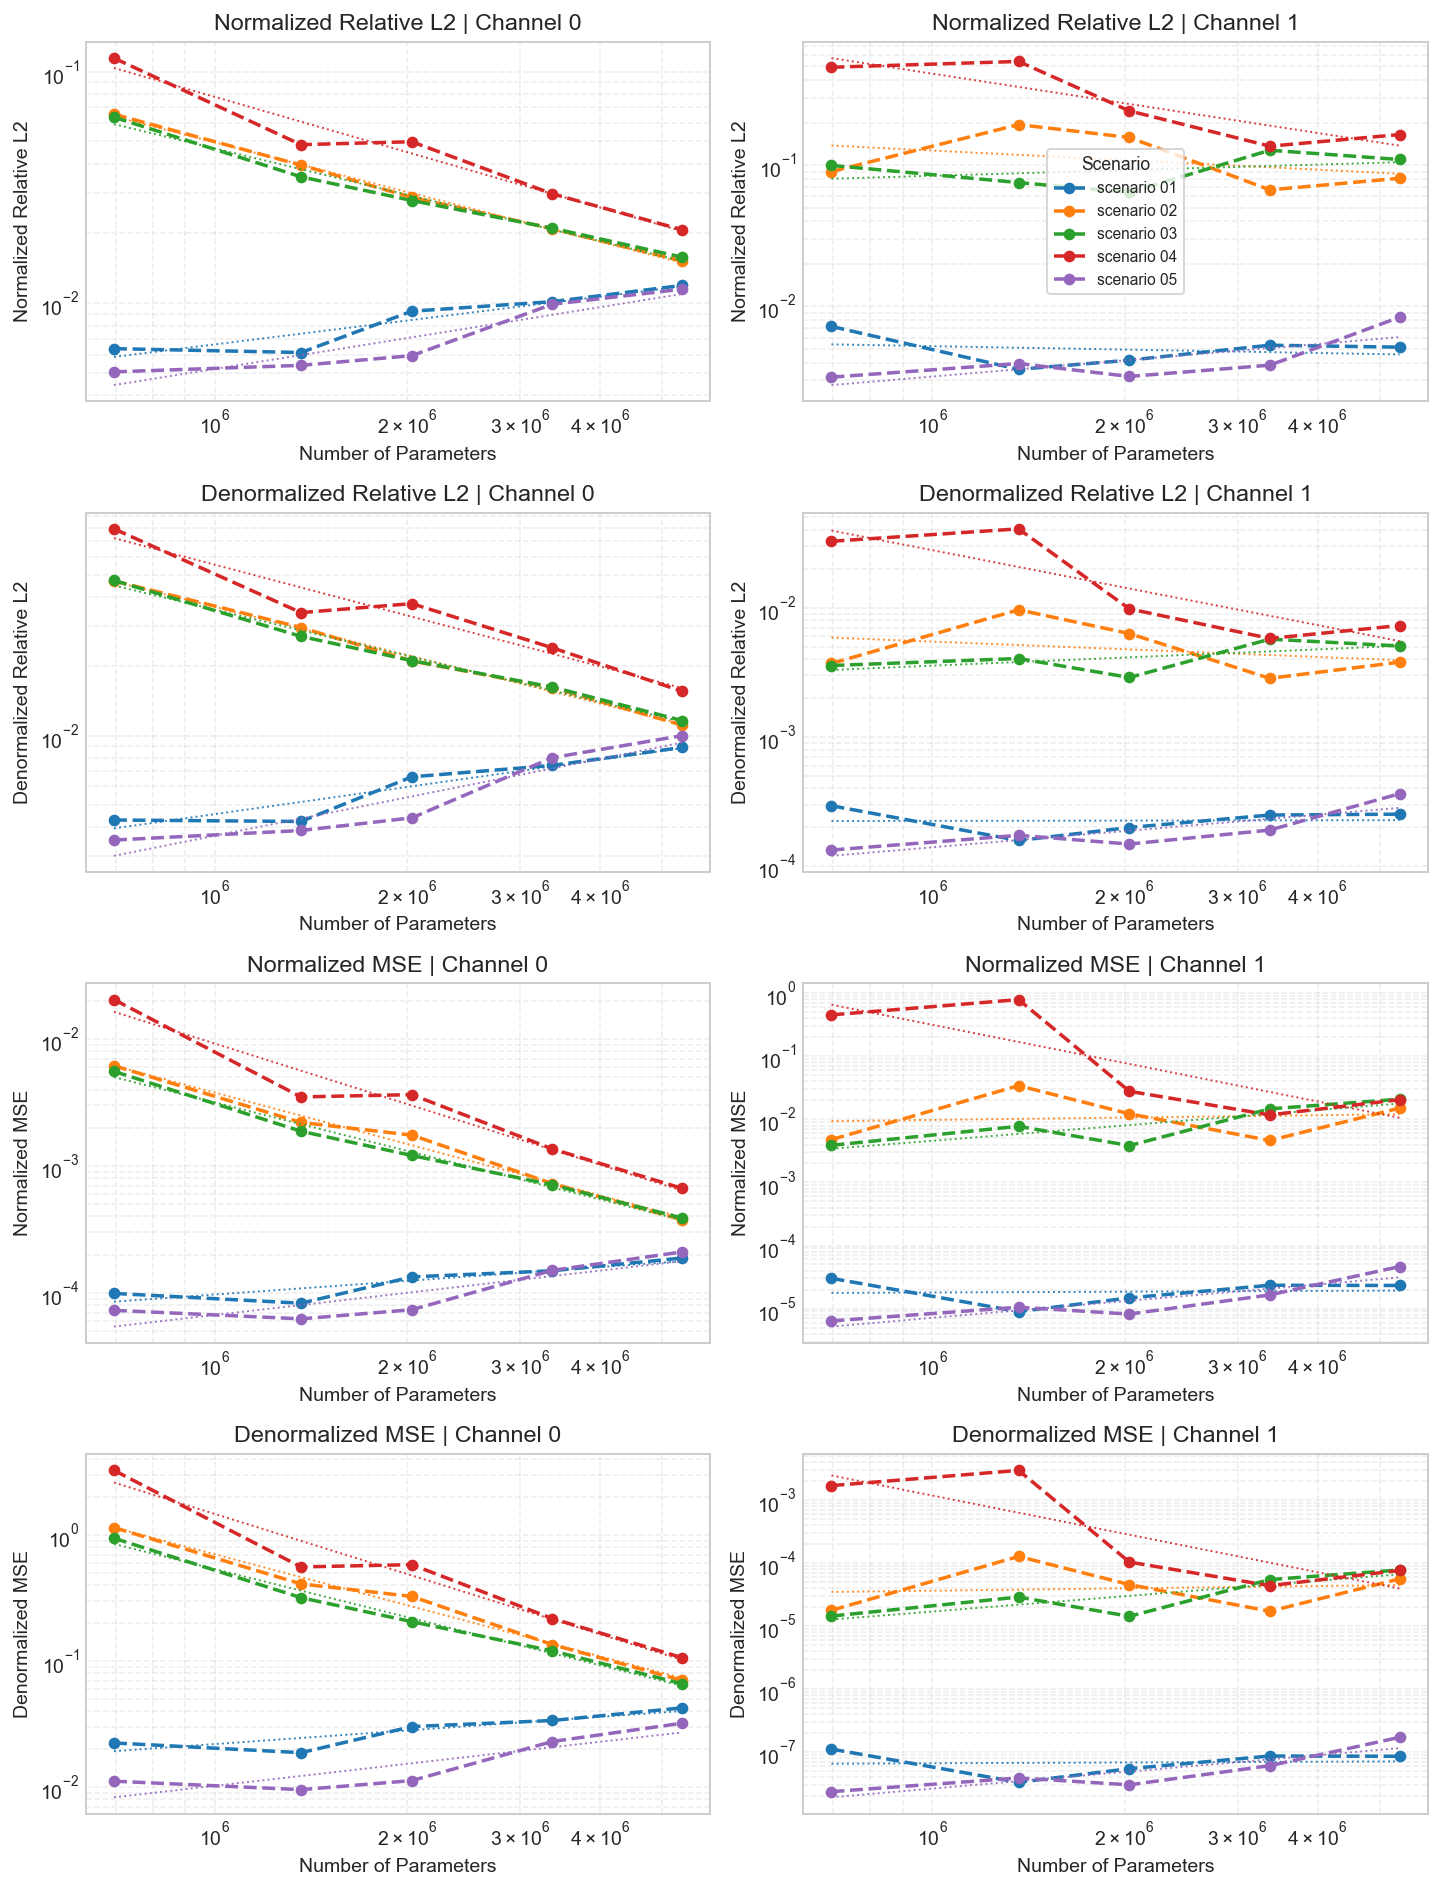

,scenario,channel,metric_key,metric_label,scaling_exponent_alpha
0,scenario_01,0,rel_l2_norm,Normalized Relative L2,-0.342949
1,scenario_02,0,rel_l2_norm,Normalized Relative L2,0.711633
2,scenario_03,0,rel_l2_norm,Normalized Relative L2,0.664973
3,scenario_04,0,rel_l2_norm,Normalized Relative L2,0.793410
4,scenario_05,0,rel_l2_norm,Normalized Relative L2,-0.442718
5,scenario_01,1,rel_l2_norm,Normalized Relative L2,0.080358
6,scenario_02,1,rel_l2_norm,Normalized Relative L2,0.224621
7,scenario_03,1,rel_l2_norm,Normalized Relative L2,-0.131741
8,scenario_04,1,rel_l2_norm,Normalized Relative L2,0.698182
9,scenario_05,1,rel_l2_norm,Normalized Relative L2,-0.382423


In [3]:
plt.style.use("seaborn-v0_8-whitegrid")

metrics_order = ["rel_l2_norm", "rel_l2_denorm", "mse_norm", "mse_denorm"]
channels = sorted(channel_df["channel"].unique())
scenarios = sorted(channel_df["scenario"].unique())
palette = plt.get_cmap("tab10")

n_rows = len(metrics_order)
n_cols = len(channels)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 3.4 * n_rows), dpi=140, squeeze=False)

scaling_rows = []

for row_idx, metric_key in enumerate(metrics_order):
    metric_label = metric_labels[metric_key]
    for col_idx, channel_idx in enumerate(channels):
        ax = axes[row_idx, col_idx]

        for scenario_idx, scenario in enumerate(scenarios):
            sub = channel_df[
                (channel_df["metric_key"] == metric_key)
                & (channel_df["channel"] == channel_idx)
                & (channel_df["scenario"] == scenario)
            ].sort_values("total_params")

            if sub.empty:
                continue

            x = sub["total_params"].to_numpy(dtype=float)
            y = sub["value"].to_numpy(dtype=float)

            ax.plot(
                x,
                y,
                marker="o",
                linestyle="--",
                linewidth=1.8,
                markersize=5,
                color=palette(scenario_idx),
                label=scenario.replace("_", " "),
            )

            finite_mask = np.isfinite(y) & (y > 0)
            if finite_mask.sum() >= 2:
                log_x = np.log10(x[finite_mask])
                log_y = np.log10(y[finite_mask])
                slope, intercept = np.polyfit(log_x, log_y, 1)
                alpha = -float(slope)
                scaling_rows.append(
                    {
                        "scenario": scenario,
                        "channel": int(channel_idx),
                        "metric_key": metric_key,
                        "metric_label": metric_label,
                        "scaling_exponent_alpha": alpha,
                    }
                )

                x_fit = np.array([x[finite_mask].min(), x[finite_mask].max()])
                y_fit = 10 ** (intercept + slope * np.log10(x_fit))
                ax.plot(x_fit, y_fit, color=palette(scenario_idx), linewidth=1.0, alpha=0.9, linestyle=":")
            else:
                scaling_rows.append(
                    {
                        "scenario": scenario,
                        "channel": int(channel_idx),
                        "metric_key": metric_key,
                        "metric_label": metric_label,
                        "scaling_exponent_alpha": np.nan,
                    }
                )

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.grid(True, which="both", linestyle="--", alpha=0.35)
        ax.set_xlabel("Number of Parameters")
        ax.set_ylabel(metric_label)
        ax.set_title(f"{metric_label} | Channel {channel_idx}")

        if row_idx == 0 and col_idx == n_cols - 1:
            ax.legend(title="Scenario", fontsize=8, title_fontsize=9, frameon=True)

plt.tight_layout()
plt.show()

scaling_df = pd.DataFrame(scaling_rows).drop_duplicates()
scaling_df.head(12)

In [4]:
best_per_channel = (
    channel_df.sort_values(["scenario", "metric_key", "channel", "value"])
    .groupby(["scenario", "metric_key", "metric_label", "channel"], as_index=False)
    .first()[["scenario", "metric_key", "metric_label", "channel", "total_params", "value"]]
    .rename(
        columns={
            "total_params": "best_total_params",
            "value": "best_metric_value",
        }
    )
)

summary = best_per_channel.merge(
    scaling_df, on=["scenario", "metric_key", "metric_label", "channel"], how="left"
).sort_values(["metric_key", "channel", "scenario"])

summary

,scenario,metric_key,metric_label,channel,best_total_params,best_metric_value,scaling_exponent_alpha
0,scenario_01,mse_denorm,Denormalized MSE,0,1364210.0,1.875626e-02,-0.359057
8,scenario_02,mse_denorm,Denormalized MSE,0,5373746.0,7.027059e-02,1.345862
16,scenario_03,mse_denorm,Denormalized MSE,0,5373746.0,6.619970e-02,1.268685
24,scenario_04,mse_denorm,Denormalized MSE,0,5373746.0,1.065625e-01,1.586649
32,scenario_05,mse_denorm,Denormalized MSE,0,1364210.0,9.540505e-03,-0.580421
1,scenario_01,mse_denorm,Denormalized MSE,1,1364210.0,3.338707e-08,-0.041601
9,scenario_02,mse_denorm,Denormalized MSE,1,3368978.0,1.725519e-05,-0.123085
17,scenario_03,mse_denorm,Denormalized MSE,1,2032466.0,1.432980e-05,-0.808195
25,scenario_04,mse_denorm,Denormalized MSE,1,3368978.0,4.391056e-05,2.020371
33,scenario_05,mse_denorm,Denormalized MSE,1,695954.0,2.372863e-08,-0.879274
